# HyperSense — Exploratory Data Analysis (EDA)

## Objective

Explore the harmonized Ghana–Benin hypertension dataset to:

- Understand the distribution of key variables
- Assess data quality and missingness
- Examine hypertension prevalence patterns
- Compare demographic, behavioral, and clinical characteristics
- Create analytical features for modelling
- Identify relationships between predictors and hypertension status

## Dataset Summary

The harmonized dataset contains respondents from:

- Ghana DHS 2014 Men (MR)
- Ghana DHS 2014 Women (IR)
- Benin DHS 2017–18 Men (MR)
- Benin DHS 2017–18 Women (IR)

Target variable:

- `htn_status`
    - 1 = Hypertensive
    - 0 = Non-hypertensive

## Workflow

1. Dataset overview
2. Missingness assessment
3. Target variable exploration
4. Demographic analysis
5. Clinical variable analysis
6. Behavioral risk factor analysis
7. Country and sex comparisons
8. Feature engineering
9. Correlation analysis
10. EDA summary and modelling recommendations

## Expected Output

A cleaned analytical dataset, key exploratory insights, engineered features, and evidence-based recommendations for machine learning model development.

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### STEP 1: Dataset Overview

In [113]:
# Load the dataset
master_df = pd.read_csv('../outputs/hypersense_master.csv')

In [114]:
# Dataset dimensions and preview
print(f"Dataset shape: {master_df.shape}")
master_df.head()

Dataset shape: (37307, 26)


,caseid,cluster,household,respondent_number,sample_weight,age,educational_level,residence,smokes_cig,smokes_pipe,...,bmi,sbp_1,sbp_2,dbp_1,dbp_2,mean_sbp,mean_dbp,gender,country,htn_status
0,1 1 1,1.0,1.0,1.0,856663.0,50.0,2.0,2.0,0.0,0.0,...,1703.0,152.0,154.0,106.0,101.0,153.0,103.5,Male,Ghana,1.0
1,1 3 1,1.0,3.0,1.0,856663.0,27.0,2.0,2.0,0.0,0.0,...,2048.0,133.0,136.0,79.0,82.0,134.5,80.5,Male,Ghana,0.0
2,1 6 1,1.0,6.0,1.0,856663.0,24.0,2.0,2.0,0.0,0.0,...,2108.0,109.0,108.0,63.0,63.0,108.5,63.0,Male,Ghana,0.0
3,111 1,1.0,11.0,1.0,856663.0,40.0,1.0,2.0,0.0,0.0,...,1972.0,117.0,117.0,84.0,82.0,117.0,83.0,Male,Ghana,0.0
4,119 1,1.0,19.0,1.0,856663.0,43.0,2.0,2.0,0.0,0.0,...,2300.0,131.0,121.0,85.0,80.0,126.0,82.5,Male,Ghana,0.0


In [115]:
# List all variables

print(f"Number of variables: {len(master_df.columns)}")
master_df.columns.tolist()

Number of variables: 26


['caseid',
 'cluster',
 'household',
 'respondent_number',
 'sample_weight',
 'age',
 'educational_level',
 'residence',
 'smokes_cig',
 'smokes_pipe',
 'chews_tobacco',
 'uses_snuff',
 'smokes_other',
 'smokes_none',
 'freq_smoke_tobacco',
 'freq_smokeless_tobacco',
 'bmi',
 'sbp_1',
 'sbp_2',
 'dbp_1',
 'dbp_2',
 'mean_sbp',
 'mean_dbp',
 'gender',
 'country',
 'htn_status']

In [116]:
# ==================================================
# Inspect variable types and completeness
# ==================================================

master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37307 entries, 0 to 37306
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   caseid                  37307 non-null  object 
 1   cluster                 37307 non-null  float64
 2   household               37307 non-null  float64
 3   respondent_number       37307 non-null  float64
 4   sample_weight           37307 non-null  float64
 5   age                     37307 non-null  float64
 6   educational_level       37307 non-null  float64
 7   residence               37307 non-null  float64
 8   smokes_cig              29708 non-null  float64
 9   smokes_pipe             29707 non-null  float64
 10  chews_tobacco           29707 non-null  float64
 11  uses_snuff              29707 non-null  float64
 12  smokes_other            29707 non-null  float64
 13  smokes_none             29708 non-null  float64
 14  freq_smoke_tobacco      23523 non-null

In [117]:
# ==================================================
# Summary statistics for numeric variables
# ==================================================

master_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cluster,37307.0,2.415115e+02,152.242702,1.0,110.0,231.0,361.0,555.0
household,37307.0,5.485635e+01,55.326367,1.0,16.0,31.0,82.0,1210.0
respondent_number,37307.0,2.849170e+00,2.796442,1.0,1.0,2.0,3.0,42.0
sample_weight,37307.0,1.000000e+06,534907.663919,94252.0,661645.0,921036.0,1208372.0,5980193.0
age,37307.0,2.989149e+01,10.730418,15.0,21.0,28.0,38.0,64.0
educational_level,37307.0,1.074865e+00,0.974448,0.0,0.0,1.0,2.0,3.0
residence,37307.0,1.542177e+00,0.498225,1.0,1.0,2.0,2.0,2.0
smokes_cig,29708.0,1.595530e-02,0.125305,0.0,0.0,0.0,0.0,1.0
smokes_pipe,29707.0,9.762009e-04,0.031229,0.0,0.0,0.0,0.0,1.0
chews_tobacco,29707.0,2.221699e-03,0.047083,0.0,0.0,0.0,0.0,1.0


In [118]:
# Respondents by country
master_df["country"].value_counts()

country
Benin    23523
Ghana    13784
Name: count, dtype: int64

In [119]:
# Respondents by gender
master_df["gender"].value_counts()

gender
Female    25324
Male      11983
Name: count, dtype: int64

In [120]:
# Respondents by country and gender
pd.crosstab(
    master_df["country"],
    master_df["gender"]
)

gender,Female,Male
country,,
Benin,15928,7595
Ghana,9396,4388


In [122]:
# ==================================================
# Percentage missing for each variable
# ==================================================

missing_pct = (
    master_df
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct.to_frame("missing_pct")

,missing_pct
sbp_2,63.165090
dbp_2,63.165090
dbp_1,63.157048
sbp_1,63.157048
bmi,57.321682
mean_sbp,45.195272
htn_status,45.195272
mean_dbp,45.189911
freq_smoke_tobacco,36.947490
freq_smokeless_tobacco,36.947490


In [123]:
# Taking a deeper look at bmi
print(master_df["bmi"].value_counts().sort_index().tail(15))
master_df.bmi.describe().T.to_frame('value')

bmi
4802.0    1
4853.0    1
4869.0    1
4884.0    1
4901.0    1
4920.0    1
4984.0    1
5007.0    1
5030.0    1
5035.0    1
5129.0    1
5324.0    1
5435.0    1
5706.0    1
9998.0    6
Name: count, dtype: int64


,value
count,15922.000000
mean,2340.958108
std,489.667466
min,1320.000000
25%,2022.000000
50%,2232.000000
75%,2542.000000
max,9998.000000


In [124]:
# ==============================================
# Fix DHS special BMI codes
# ==============================================

# Recode DHS special BMI values (9998) to missing
master_df["bmi"] = master_df["bmi"].replace(9998, np.nan)

# Verify correction
master_df["bmi"].describe().to_frame('value')

,value
count,15916.000000
mean,2338.071563
std,466.639588
min,1320.000000
25%,2022.000000
50%,2232.000000
75%,2541.250000
max,5706.000000


### Key Dataset Facts

The harmonized HyperSense dataset contains **37,307 respondents** and **26 variables** pooled from four DHS surveys:

| Dataset | n |
|----------|----------:|
| Ghana Men | 4,388 |
| Ghana Women | 9,396 |
| Benin Men | 7,595 |
| Benin Women | 15,928 |

### Population Profile

- Mean age: **29.9 years**
- Age range: **15–64 years**
- Female respondents: **25,324 (67.9%)**
- Male respondents: **11,983 (32.1%)**

### Blood Pressure Coverage

Hypertension status was available for **20,446 respondents (54.8%)**, while **16,861 (45.2%)** had no BP measurements due to DHS survey design and module differences.

### Missingness Summary

Missing values were concentrated in:

- Blood pressure variables
- BMI
- Tobacco frequency variables

These patterns largely reflect differences in DHS data collection procedures rather than data processing errors.

The final modeling dataset will be restricted to respondents with valid hypertension outcome measurements.

### STEP 2: Missingness Assessment

In [125]:
# Missingness summary
missing_pct.to_frame('missing_pct')

,missing_pct
sbp_2,63.165090
dbp_2,63.165090
dbp_1,63.157048
sbp_1,63.157048
bmi,57.321682
mean_sbp,45.195272
htn_status,45.195272
mean_dbp,45.189911
freq_smoke_tobacco,36.947490
freq_smokeless_tobacco,36.947490


In [130]:
# % Missing HTN status by country and sex
(
    master_df
    .groupby(["country", "gender"])["htn_status"]
    .apply(lambda x: x.isna().mean() * 100)
    .to_frame("missing_htn_pct")
)

missing_htn_pct
country gender                 
Benin   Female        80.769714
        Male          52.113232
Ghana   Female         0.287356
        Male           0.250684

In [131]:
# Available BP measurements by country and sex
(
    master_df
    .groupby(["country", "gender"])["htn_status"]
    .count()
    .to_frame("measured_respondents")
)

measured_respondents
country gender                      
Benin   Female                  3063
        Male                    3637
Ghana   Female                  9369
        Male                    4377

#### Missingness Assessment

Missingness was concentrated in blood pressure, BMI, and tobacco frequency variables. These patterns were expected and primarily reflect differences in DHS survey modules across countries and sexes rather than data processing issues.

Hypertension status was available for 20,446 respondents. Coverage was highest in Ghana and substantially lower in Benin, particularly among women. Consequently, the final modelling dataset will be restricted to respondents with valid hypertension outcome measurements.

#### STEP 3: Target Variable Exploration

In [143]:
# Overall hypertension prevalence
htn_counts = master_df["htn_status"].value_counts(dropna=False)
htn_pct = master_df["htn_status"].value_counts(normalize=True, dropna=False) * 100

print(htn_counts.to_frame('Counts'))
print()
print(htn_pct.round(2).to_frame('Percentages'))

            Counts
htn_status        
0.0          18097
NaN          16861
1.0           2349

            Percentages
htn_status             
0.0               48.51
NaN               45.20
1.0                6.30


In [147]:
# Hypertension prevalence among measured respondents
measured_df = master_df.dropna(subset=["htn_status"])

(
    measured_df["htn_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("prevalence_pct")
)

,prevalence_pct
htn_status,
0.0,88.51
1.0,11.49


In [150]:
# HTN prevalence by country and sex among measured respondents
(
    measured_df
    .groupby(["country", "gender"], observed=True)["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

htn_prevalence_pct
country gender                    
Benin   Female               12.90
        Male                 16.47
Ghana   Female                9.01
        Male                 11.67

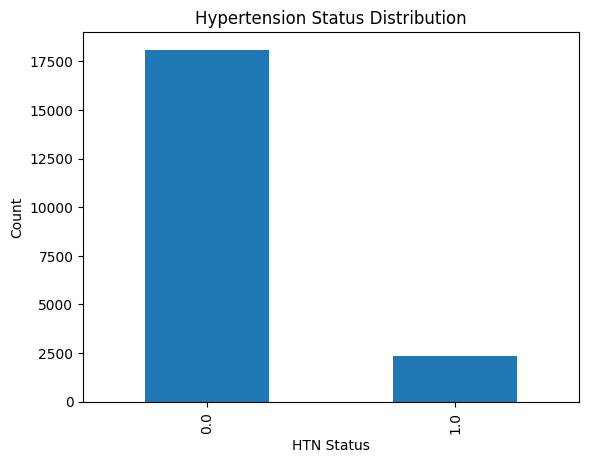

In [151]:
# Overall HTN distribution
(
    measured_df["htn_status"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Hypertension Status Distribution")
plt.xlabel("HTN Status")
plt.ylabel("Count")
plt.show()

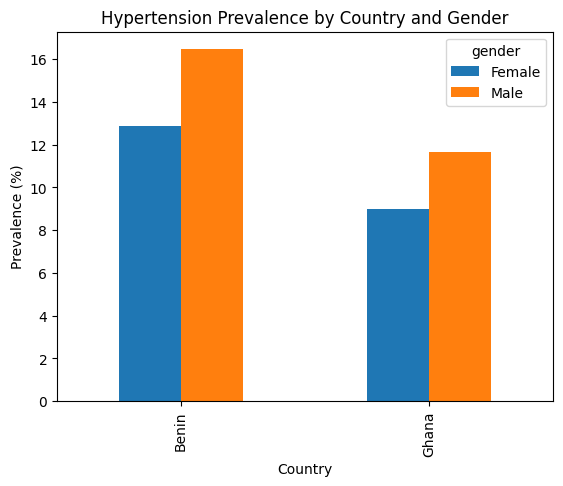

In [154]:
# HTN prevalence by country and sex
(
    measured_df
    .groupby(["country", "gender"])["htn_status"]
    .mean()
    .mul(100)
    .unstack()
    .plot(kind="bar")
)

plt.title("Hypertension Prevalence by Country and Gender")
plt.ylabel("Prevalence (%)")
plt.xlabel("Country")
plt.show()